<a href="https://colab.research.google.com/github/kaynalian/Jobsheet-Pengolahan-Citra_Kartika-Yuliana_IK-3D/blob/main/Jobsheet04_SEGMENTASI_GAMBAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

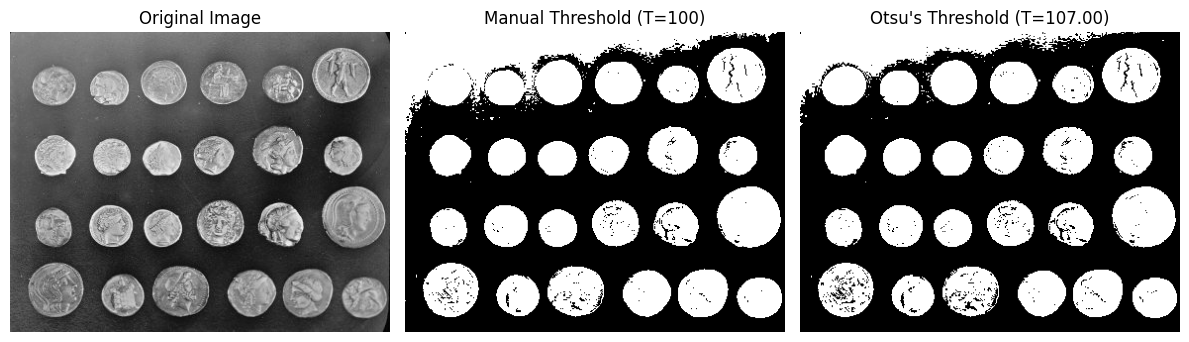

In [2]:
import matplotlib.pyplot as plt
from skimage import data, filters

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()  # Citra sudah grayscale

# 2. Thresholding Global (manual)
# Tentukan nilai ambang manual, misal 100
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# 4. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

# Gambar asli
ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

# Threshold manual
ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

# Threshold Otsu
ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f"Otsu's Threshold (T={thresh_otsu:.2f})")
ax[2].axis('off')

plt.tight_layout()
plt.show()


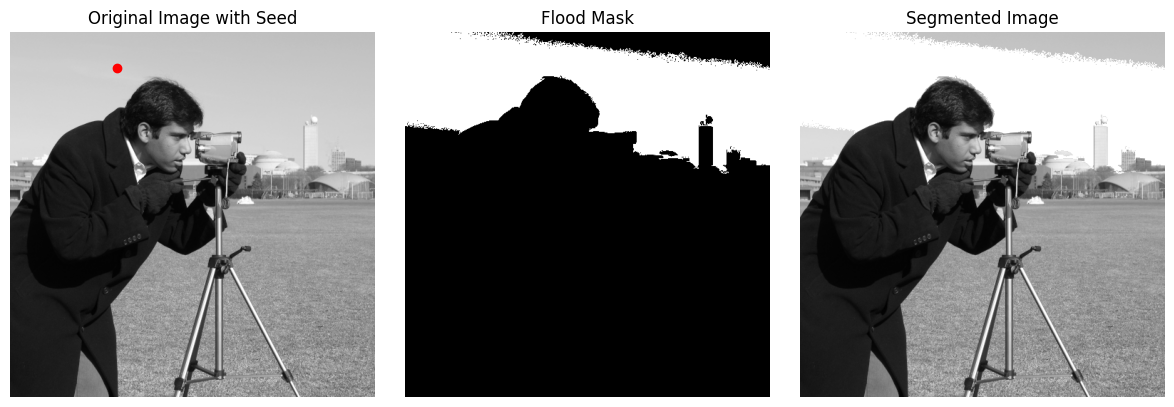

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation

# 1. Memuat citra
image_camera = data.camera()

# 2. Tentukan seed point
seed_point = (50, 150)

# 3. Flood (region growing)
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# 4. Buat citra segmentasi
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255

# 5. Visualisasi
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap='gray')
ax[0].plot(seed_point[1], seed_point[0], 'ro')
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap='gray')
ax[1].set_title('Flood Mask')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap='gray')
ax[2].set_title('Segmented Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()

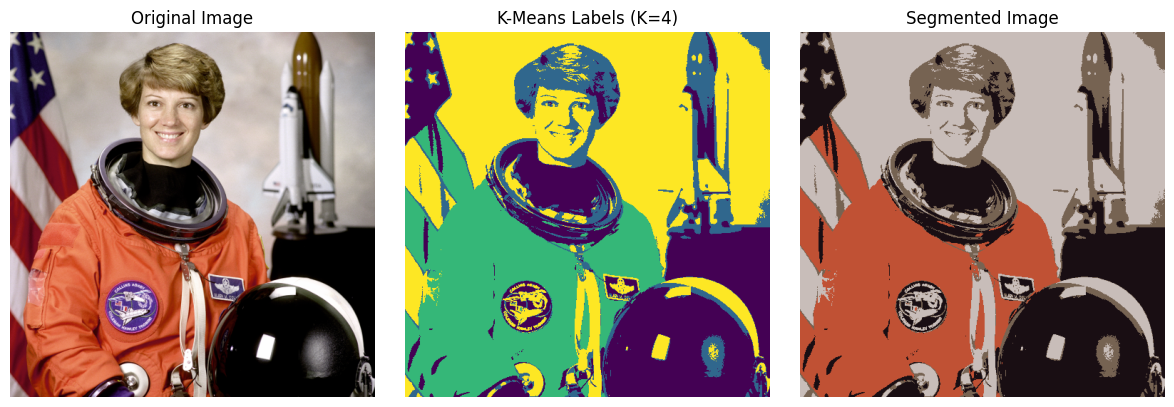

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# 1. Load gambar
image_astro = data.astronaut()
image_astro_float = image_astro.astype(float) / 255.0

# 2. Konversi ke LAB & reshape
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

# 3. K-Means
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# 4. Bentuk ulang label
segmented_labels = pixel_labels.reshape(rows, cols)

# 5. Buat gambar segmentasi
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_

for k in range(n_clusters):
    mask = (pixel_labels == k).reshape(rows, cols)
    segmented_image_kmeans[mask] = centers_lab[k]

# Konversi ke RGB
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# 6. Visualisasi
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

ax[2].imshow(segmented_image_rgb)
ax[2].set_title('Segmented Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()

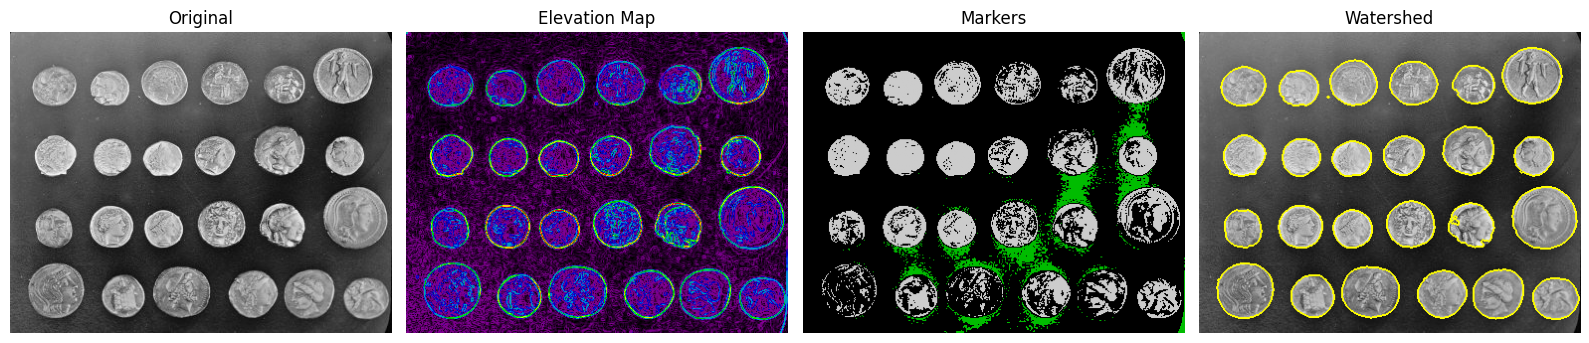

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation

# 1. Load citra
image_coins = data.coins()

# 2. Gradient (topografi)
elevation_map = filters.sobel(image_coins)

# 3. Marker
markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1
markers[image_coins > 150] = 2

# 4. Watershed
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# 5. Boundary
segmented_colored = segmentation.mark_boundaries(image_coins, segmentation_watershed)

# 6. Visualisasi
fig, axes = plt.subplots(ncols=4, figsize=(16, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap='nipy_spectral')
ax[1].set_title('Elevation Map')
ax[1].axis('off')

ax[2].imshow(markers, cmap='nipy_spectral')
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.tight_layout()
plt.show()

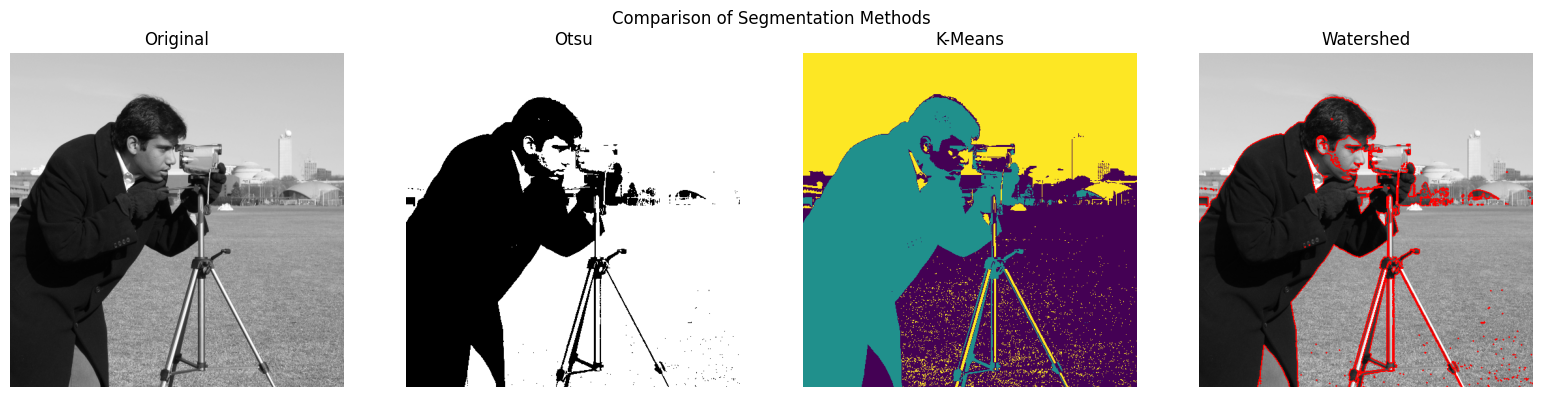

In [7]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float
from sklearn.cluster import KMeans
import numpy as np
import warnings

# 1. Load citra
image = data.camera()
image_float = img_as_float(image)

# 2a. Otsu
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# 2b. K-Means
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_kmeans = pixel_labels.reshape(rows, cols)

# 2c. Watershed
elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2

segmentation_watershed = segmentation.watershed(elevation_map, markers)

segmented_ws = segmentation.mark_boundaries(image_float, segmentation_watershed, color=(1, 0, 0))

# 3. Visualisasi
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
ax = axes.ravel()

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title('Otsu')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans, cmap='viridis')
ax[2].set_title('K-Means')
ax[2].axis('off')

ax[3].imshow(segmented_ws)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout()
plt.show()

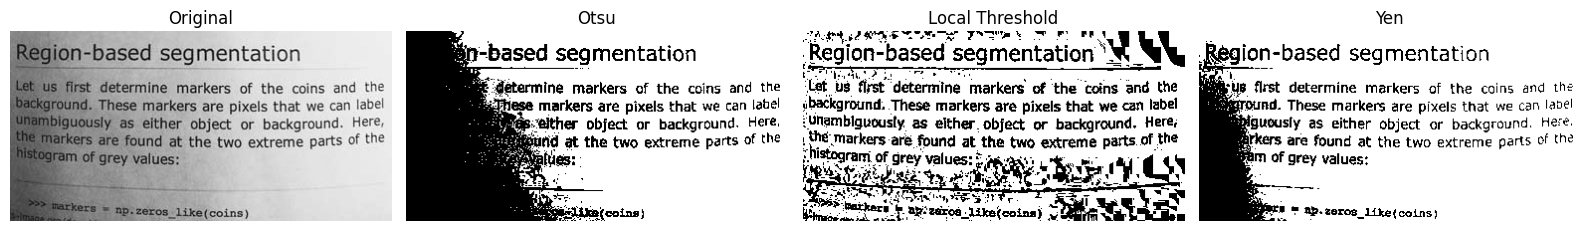

In [8]:
import matplotlib.pyplot as plt
from skimage import data, filters
import numpy as np

# 1. Load citra
image = data.page()

# 2. Otsu
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# 3. Threshold Local (adaptive)
block_size = 35
local_thresh = filters.threshold_local(image, block_size)
binary_local = image > local_thresh

# 4. Threshold Yen
thresh_yen = filters.threshold_yen(image)
binary_yen = image > thresh_yen

# 5. Visualisasi
fig, axes = plt.subplots(1, 4, figsize=(16,4))
ax = axes.ravel()

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title('Otsu')
ax[1].axis('off')

ax[2].imshow(binary_local, cmap='gray')
ax[2].set_title('Local Threshold')
ax[2].axis('off')

ax[3].imshow(binary_yen, cmap='gray')
ax[3].set_title('Yen')
ax[3].axis('off')

plt.tight_layout()
plt.show()

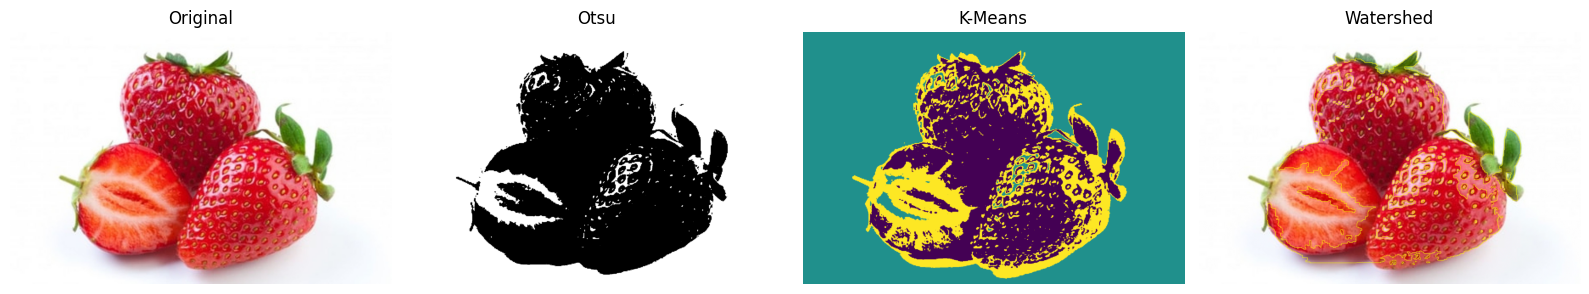

In [11]:
import matplotlib.pyplot as plt
from skimage import io, filters, segmentation, color
from sklearn.cluster import KMeans
import numpy as np

# 1. Load gambar
image = io.imread('buah.jpg')
gray = color.rgb2gray(image)

# ======================
# 2. OTSU
# ======================
thresh = filters.threshold_otsu(gray)
binary_otsu = gray > thresh

# ======================
# 3. K-MEANS
# ======================
pixels = image.reshape(-1, 3)

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
labels = kmeans.fit_predict(pixels)

segmented_kmeans = labels.reshape(image.shape[:2])

# ======================
# 4. WATERSHED
# ======================
gradient = filters.sobel(gray)

# PERBAIKAN: harus integer
markers = np.zeros_like(gray, dtype=np.int32)
markers[gray < 0.3] = 1
markers[gray > 0.7] = 2

watershed = segmentation.watershed(gradient, markers)

# boundary biar jelas
watershed_result = segmentation.mark_boundaries(image, watershed)

# ======================
# 5. VISUALISASI
# ======================
fig, ax = plt.subplots(1, 4, figsize=(16,4))

ax[0].imshow(image)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title('Otsu')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans, cmap='viridis')
ax[2].set_title('K-Means')
ax[2].axis('off')

ax[3].imshow(watershed_result)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.tight_layout()
plt.show()